# High Frequency Data and Limit Order Books
## Lab 5: Propagator Models

AMRI Imad, CHIBA Nesrine, JAMAL Adonis

This notebook implements the propagator models for trades and LOB events as described in Lecture 6 and Eisler et al. (2012).

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import gc

In [18]:
# Load all trades and updates
print("Loading data...")
trades = np.array([[pd.read_csv(f"Data/stock{i}_day{j}_trades.csv.gz") for i in range(0, 3)] for j in range(0, 5)], dtype=object)
df_trades = pd.concat([df.assign(stock=i, day=j) for (j, i), df in np.ndenumerate(trades)], ignore_index=True)

updates = np.array([[pd.read_csv(f"Data/stock{i}_day{j}_updates.csv.gz") for i in range(0, 3)] for j in range(0, 5)], dtype=object)
df_updates = pd.concat([df.assign(stock=i, day=j) for (j, i), df in np.ndenumerate(updates)], ignore_index=True)
del trades, updates
gc.collect()

df_trades['ts'] = pd.to_datetime(df_trades['ts'])
df_updates['ts'] = pd.to_datetime(df_updates['ts'])

print("Total trades:", len(df_trades))

Loading data...
Total trades: 259694


## Part 1: A propagator model for trades

1. Compute the response function for trades in trade time

Processing stock 0...
Processing stock 1...
Processing stock 2...


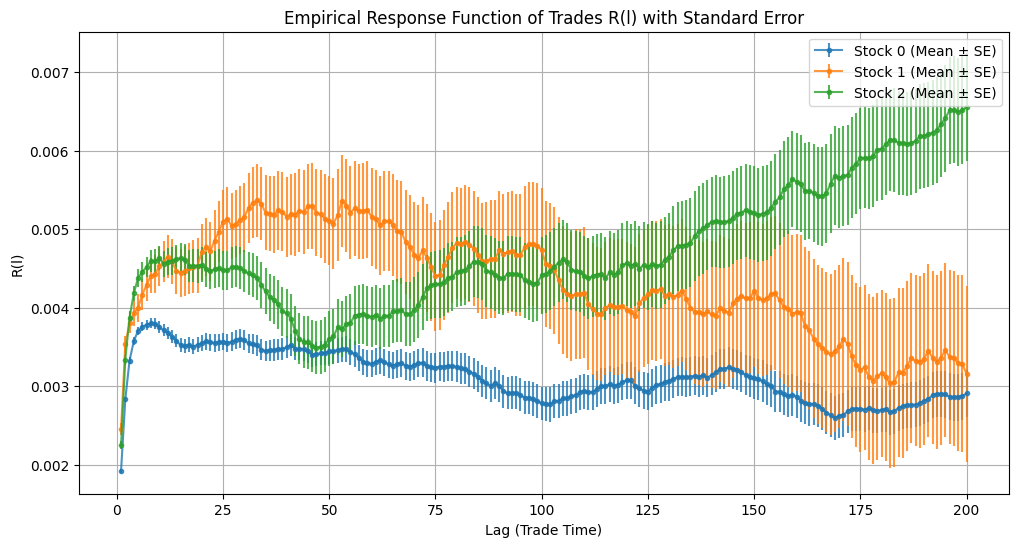

In [19]:
# Process stock by stock
stocks = [0, 1, 2]
lags = np.arange(1, 201)

stock_R = {}
stock_R_std = {}
stock_S_history = {}
stock_r_history = {}

plt.figure(figsize=(12, 6))

for s in stocks:
    print(f"Processing stock {s}...")
    df_t_s = df_trades[df_trades['stock'] == s].copy()
    df_u_s = df_updates[df_updates['stock'] == s].copy()
    
    # Aggregate across days, keep track of day boundaries
    sum_responses = np.zeros(len(lags))
    sum_sq_responses = np.zeros(len(lags))
    count_responses = np.zeros(len(lags))
    
    all_S_for_stock = []
    all_r_for_stock = []
    
    for d in range(5):
        t_day = df_t_s[df_t_s['day'] == d].sort_values('ts')
        u_day = df_u_s[df_u_s['day'] == d].sort_values('ts')
        
        # Merge_asof to get mid price just before trade
        t_day = pd.merge_asof(t_day, u_day[['ts', 'bp', 'ap']], on='ts', direction='backward')
        t_day = t_day.dropna(subset=['bp', 'ap']).copy()
        
        t_day['mid'] = (t_day['bp'] + t_day['ap']) / 2
        t_day['sign'] = np.where(t_day['price'] >= t_day['ap'], 1, 
                                 np.where(t_day['price'] <= t_day['bp'], -1, 0))
        t_day = t_day[t_day['sign'] != 0].copy()
        
        S = t_day['sign'].values
        P = t_day['mid'].values
        r = np.diff(P) # r_n = p_{n+1} - p_n
        
        all_S_for_stock.append(S)
        all_r_for_stock.append(r)
        
        for idx, l in enumerate(lags):
            if len(P) > l:
                shift_P = P[l:]
                valid_S = S[:-l]
                valid_P = P[:-l]
                
                resp = (shift_P - valid_P) * valid_S
                sum_responses[idx] += np.sum(resp)
                sum_sq_responses[idx] += np.sum(resp**2)
                count_responses[idx] += len(valid_S)
    
    R_l = sum_responses / count_responses
    std_l = np.sqrt(np.maximum(0, sum_sq_responses / count_responses - R_l**2))
    stderr_l = std_l / np.sqrt(count_responses)
    
    stock_R[s] = R_l
    stock_R_std[s] = std_l
    stock_S_history[s] = all_S_for_stock
    stock_r_history[s] = all_r_for_stock
    
    # error bars
    plt.errorbar(lags, R_l, yerr=stderr_l, marker='.', label=f'Stock {s} (Mean ± SE)', alpha=0.8)

plt.title('Empirical Response Function of Trades R(l) with Standard Error')
plt.xlabel('Lag (Trade Time)')
plt.ylabel('R(l)')
plt.legend()
plt.grid(True)
plt.show()

2. Calibrate a propagator model for trades.

Stock 0 R_model(l) vs R(l) MSE: 9.804408e-11
Stock 1 R_model(l) vs R(l) MSE: 5.449378e-08
Stock 2 R_model(l) vs R(l) MSE: 8.319265e-10


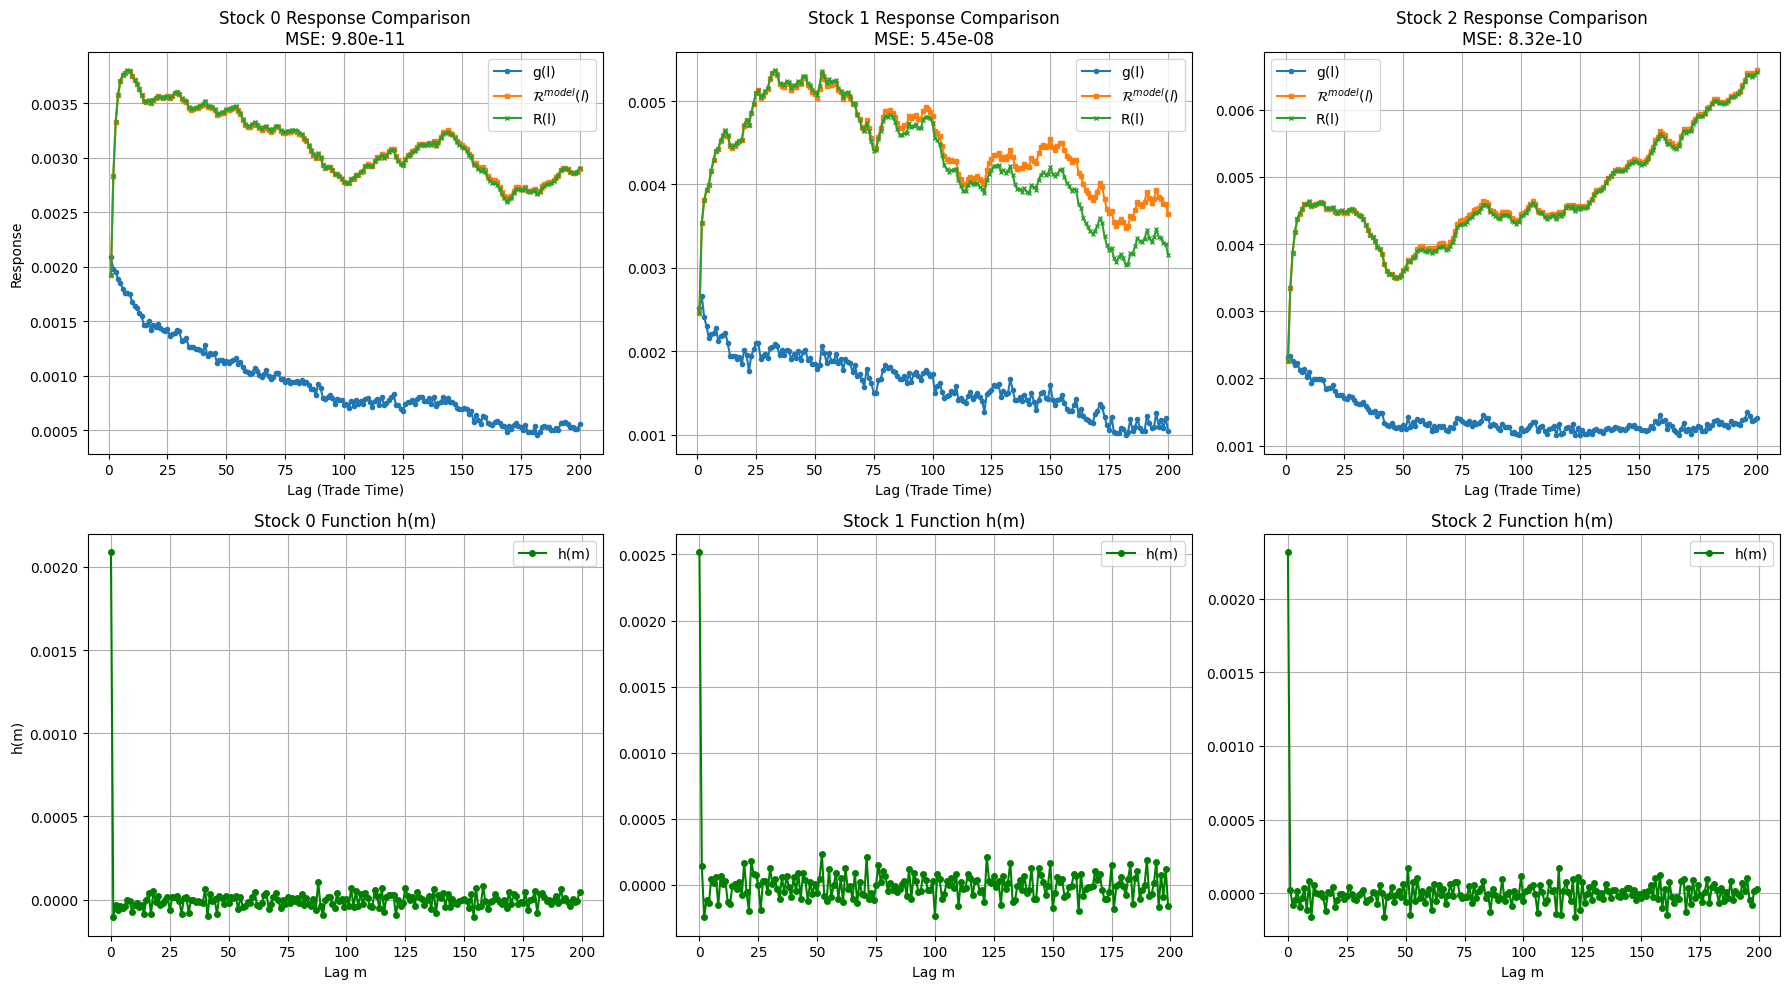

In [20]:
L = 200 # truncate at lag L
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx_s, s in enumerate(stocks):
    # Aggregate C(k) and C_re(l) across days
    sum_C = np.zeros(L)
    count_C = np.zeros(L)
    sum_Cre = np.zeros(L)
    count_Cre = np.zeros(L)
    
    for S, r in zip(stock_S_history[s], stock_r_history[s]):
        N = len(S)
        Nr = len(r)
        
        for k in range(L):
            if N > k:
                if k == 0:
                    sum_C[k] += np.sum(S * S)
                    count_C[k] += N
                else:
                    sum_C[k] += np.sum(S[:-k] * S[k:])
                    count_C[k] += (N - k)
        
        for l in range(L):
            if Nr > l:
                sum_Cre[l] += np.sum(r[l:] * S[:Nr-l])
                count_Cre[l] += (Nr - l)
                
    C = sum_C / count_C
    C_re = sum_Cre / count_Cre
    
    # Linear system: C_re(l) = sum_{m=0}^{L-1} h(m) C(|l-m|)
    M = np.array([[C[abs(i - j)] for j in range(L)] for i in range(L)])
    h = np.linalg.solve(M, C_re)
    
    # Recover g(l)
    g = np.zeros(L + 1)
    g[1:] = np.cumsum(h)
    g_plot = g[1:]

    # Model response: R_model(l) = sum_{j=0}^{l-1} sum_m h(m) C(|j-m|)
    R_model = np.zeros(L)
    for l in range(1, L + 1):
        total = 0.0
        for j in range(l):
            for m in range(L):
                total += h[m] * C[abs(j - m)]
        R_model[l - 1] = total

    R_trunc = stock_R[s][:L]
    mse_model = np.mean((R_model - R_trunc)**2)
    print(f"Stock {s} R_model(l) vs R(l) MSE: {mse_model:.6e}")

    ax_g = axes[0, idx_s]
    ax_g.plot(np.arange(1, L+1), g_plot, label='g(l)', marker='o', markersize=3)
    ax_g.plot(np.arange(1, L+1), R_model, label=r'$\mathcal{R}^{model}(l)$', marker='s', markersize=3)
    ax_g.plot(np.arange(1, L+1), R_trunc, label='R(l)', marker='x', markersize=3)
    ax_g.set_title(f'Stock {s} Response Comparison\nMSE: {mse_model:.2e}')
    ax_g.set_xlabel('Lag (Trade Time)')
    if idx_s == 0: ax_g.set_ylabel('Response')
    ax_g.legend()
    ax_g.grid(True)
    
    # h(m)
    ax_h = axes[1, idx_s]
    ax_h.plot(np.arange(0, L), h, label='h(m)', marker='o', markersize=4, color='green')
    ax_h.set_title(f'Stock {s} Function h(m)')
    ax_h.set_xlabel('Lag m')
    if idx_s == 0: ax_h.set_ylabel('h(m)')
    ax_h.legend()
    ax_h.grid(True)

plt.tight_layout()
plt.show()

3. Comment.

<blockquote>

For each of the three stocks, the function $h(m)$ initially decreases rapidly as the lag increases from 0, but then stabilizes starting from $m \approx 2$. This reflects the direct impact of a trade on future price changes is strongest immediately after the trade, but quickly weakens as more trades occur.

$g(l)$ and $\mathcal{R}(l)$ do not coincide exactly. The equality $\mathcal{R}(l) = g(l)$ is true if $\epsilon_n$'s are i.i.d. which is clearly not the case here. This shows the presence of memory and correlation in the order flow: trade signs are not independent, and this autocorrelation structure must be accounted for in the model. The propagator model is consistent with approximately uncorrelated returns because $h(m)$ decays fast enough that the correlated sign contributions and the kernel combine to produce near-zero return autocorrelation (the "diffusivity condition").

We thus check the calibration using the sign-return lagged covariance $C^{r, \epsilon} (l) = \mathbb{E}[r_{n+l} \epsilon_n] = \sum_{m \geq 0} h(m) C(|m - l|)$. Comparing the result to the $\mathcal{R}(l)$, we find a much better agreement, with MSE values of the order of $10^{-8}$ or even smaller, as the two curves are almost indistinguishable for small lag values. This shows that the propagator model can accurately capture the average price response when the true correlation structure of the order flow is included, and can describe the impact of trades on prices as long as the correct order flow statistics are used.

In practice, this figure shows that while the immediate impact of a trade is important, the history and correlation of past trades play an important role in the shape of the observed price dynamics.

It is important to note that the MSE between $\mathcal{R}(l)$ and $g(l)$ is still very small, but comparatively larger than the MSE between $\mathcal{R}(l)$ and $C^{r, \epsilon} (l)$.

</blockquote>

## Part 2: A propagator model for LOB events

Select one stock of your dataset (stock0 or stock1).

We will use stock0.

In [21]:
# Prepare event data
stk = 0
df_t_s0 = df_trades[df_trades['stock'] == stk].copy()
df_u_s0 = df_updates[df_updates['stock'] == stk].copy()

events_per_day = []

def classify_lob_event(row):
    t = row['type']
    if t == 'T':
        if row['price'] >= row['ap']:
            sign = 1
        elif row['price'] <= row['bp']:
            sign = -1
        else:
            return 'UNKNOWN', 0, 0.0

        ap_d = row.get('ap_diff', 0) or 0
        bp_d = row.get('bp_diff', 0) or 0
        if (sign == 1 and ap_d > 0) or (sign == -1 and bp_d < 0):
            gap = abs(ap_d if sign == 1 else bp_d) / 2.0
            return "MO'", sign, gap
        else:
            return 'MO0', sign, 0.0

    elif t == 'U':
        ap_d = row.get('ap_diff', 0) or 0
        bp_d = row.get('bp_diff', 0) or 0
        aq_d = row.get('aq_diff', 0) or 0
        bq_d = row.get('bq_diff', 0) or 0

        if bp_d > 0:
            return "LO'", 1, bp_d / 2.0
        if ap_d < 0:
            return "LO'", -1, abs(ap_d) / 2.0

        if bp_d < 0:
            return "CA'", -1, abs(bp_d) / 2.0
        if ap_d > 0:
            return "CA'", 1, ap_d / 2.0

        if bq_d > 0:
            return 'LO0', 1, 0.0
        if aq_d > 0:
            return 'LO0', -1, 0.0

        if bq_d < 0:
            return 'CA0', -1, 0.0
        if aq_d < 0:
            return 'CA0', 1, 0.0

    return 'UNKNOWN', 0, 0.0

def assign_side(event_type, sign):
    """Side s_t: +1 = bid-side event, -1 = ask-side event."""
    if event_type.startswith('MO'):
        return -sign
    elif event_type.startswith('LO'):
        return sign
    elif event_type.startswith('CA'):
        return -sign
    return 0

all_bp = df_u_s0['bp'].dropna()
all_ap = df_u_s0['ap'].dropna()
diffs = np.abs(np.diff(np.sort(np.unique(np.concatenate([all_bp.values, all_ap.values])))))
tick_size = diffs[diffs > 1e-10].min()

for d in range(5):
    u_day = df_u_s0[df_u_s0['day'] == d].sort_values('ts').copy()
    u_day['bp_diff'] = u_day['bp'].diff().fillna(0)
    u_day['bq_diff'] = u_day['bq'].diff().fillna(0)
    u_day['ap_diff'] = u_day['ap'].diff().fillna(0)
    u_day['aq_diff'] = u_day['aq'].diff().fillna(0)
    
    # Trade prices to identify market orders
    t_day = df_t_s0[df_t_s0['day'] == d].sort_values('ts')[['ts', 'price']].copy()
    t_day = t_day.groupby('ts').last().reset_index()
    u_day = pd.merge(u_day, t_day, on='ts', how='left').copy()
    u_day['type'] = np.where(u_day['price'].notna(), 'T', 'U')

    classified = u_day.apply(classify_lob_event, axis=1)
    u_day['event_type'] = [c[0] for c in classified]
    u_day['sign'] = [float(c[1]) for c in classified]
    u_day['gap'] = [c[2] for c in classified]
    u_day['side'] = [assign_side(et, s) for et, s in zip(u_day['event_type'], u_day['sign'])]
    
    u_day = u_day[u_day['event_type'] != 'UNKNOWN'].copy()
    u_day['mid'] = (u_day['bp'] + u_day['ap']) / 2
    u_day['pre_mid'] = u_day['mid'].shift(1).bfill()
    u_day.reset_index(drop=True, inplace=True)
    events_per_day.append(u_day.dropna(subset=['mid']))

print(f"Prepared event data for stock {stk} across 5 days.")
print("Event counts day 0:\n", events_per_day[0]['event_type'].value_counts())

Prepared event data for stock 0 across 5 days.
Event counts day 0:
 event_type
LO0    99385
CA0    94043
LO'    10880
CA'     8271
MO0     7191
MO'       16
Name: count, dtype: int64


1. Plot the sign $\langle \epsilon_{t}, \epsilon_{t+l} \rangle$ and side autocorrelation $\langle s_t, s_{t+l} \rangle$ functions.

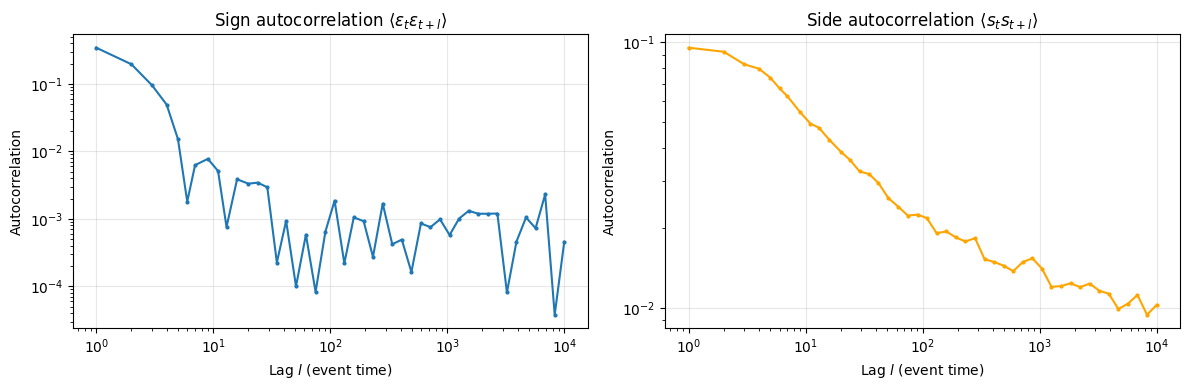

In [22]:
lags = np.unique(np.logspace(0.0, 4.0, num=50, dtype=int))
sign_acf = np.zeros(len(lags))
side_acf = np.zeros(len(lags))
counts_acf = np.zeros(len(lags))

for u_day in events_per_day:
    S = u_day['sign'].values
    Side = u_day['side'].values
    
    for idx, l in enumerate(lags):
        if len(S) > l:
            if l == 0:
                shift_S, shift_Side = S, Side
                curr_S, curr_Side = S, Side
            else:
                shift_S, shift_Side = S[l:], Side[l:]
                curr_S, curr_Side = S[:-l], Side[:-l]
            
            sign_acf[idx] += np.sum(curr_S * shift_S)
            side_acf[idx] += np.sum(curr_Side * shift_Side)
            counts_acf[idx] += (len(S) - l)

sign_acf /= counts_acf
side_acf /= counts_acf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(lags, np.abs(sign_acf), marker='.', markersize=4)
axes[0].set_title(r'Sign autocorrelation $\langle \epsilon_t \epsilon_{t+l} \rangle$')
axes[0].set_xlabel(r'Lag $l$ (event time)')
axes[0].set_ylabel('Autocorrelation')
axes[0].grid(True, alpha=0.3)

axes[1].loglog(lags, np.abs(side_acf), marker='.', markersize=4, color='orange')
axes[1].set_title(r'Side autocorrelation $\langle s_t s_{t+l} \rangle$')
axes[1].set_xlabel(r'Lag $l$ (event time)')
axes[1].set_ylabel('Autocorrelation')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We observe in the above autocorrelation plots similar dynamics to those seen in the lecture slides page 39. Notably, both the sign and side autocorrelation functions exhibit a slow decay, indicating the presence of long-range memory in the order flow. Market orders persistently hit one side, and attract liquidity on the same side, which is consistent with the observed positive autocorrelation in both sign and side.

2. Compute and plot the empirical response function $\mathcal{R}_\pi (l)$ for each of the $6$ types of events $\pi$. Comment.

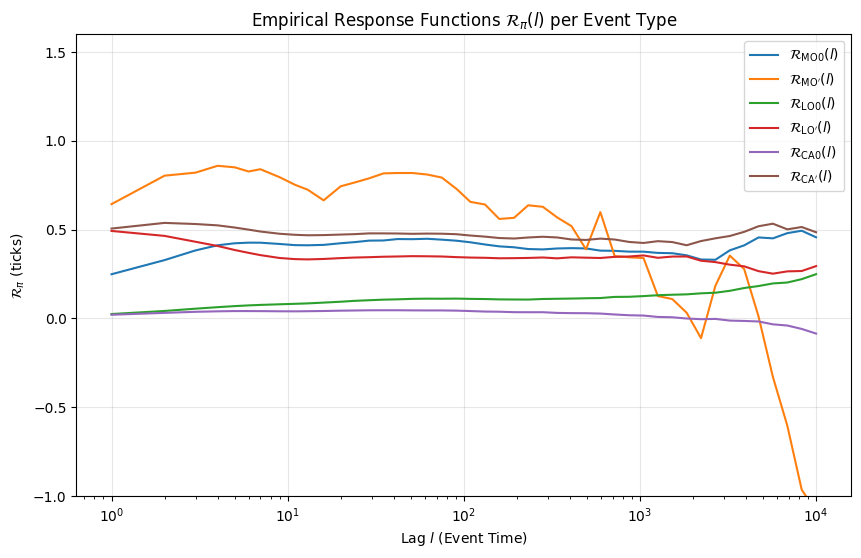

In [28]:
types = ["MO0", "MO'", "LO0", "LO'", "CA0", "CA'"]
lags = np.unique(np.logspace(0.0, 4.0, num=50, dtype=int))

R_pi_sum = {pi: np.zeros(len(lags)) for pi in types}
R_pi_count = {pi: np.zeros(len(lags)) for pi in types}

for u_day in events_per_day:
    P = u_day['mid'].values        # post-event mid (future prices)
    P0 = u_day['pre_mid'].values   # pre-event mid (baseline)
    S = u_day['sign'].values
    E = u_day['event_type'].values
    
    for idx, l in enumerate(lags):
        if len(P) > l:
            shift_P = P[l:]         # future post-event price at t+l
            valid_P0 = P0[:-l]      # pre-event price at t
            diff_P = (shift_P - valid_P0) / tick_size  # in ticks
            
            valid_S = S[:-l]
            valid_E = E[:-l]
            
            for pi in types:
                mask = (valid_E == pi)
                if np.sum(mask) > 0:
                    R_pi_sum[pi][idx] += np.sum(diff_P[mask] * valid_S[mask])
                    R_pi_count[pi][idx] += np.sum(mask)

R_pi = {pi: R_pi_sum[pi] / np.maximum(R_pi_count[pi], 1) for pi in types}

plt.figure(figsize=(10, 6))
for pi in types:
    plt.semilogx(lags, R_pi[pi], label=f"$\\mathcal{{R}}_{{\\mathrm{{{pi}}}}}(l)$")
plt.title('Empirical Response Functions $\\mathcal{R}_\\pi(l)$ per Event Type')
plt.ylim(-1.0, 1.6)
plt.xlabel('Lag $l$ (Event Time)')
plt.ylabel('$\\mathcal{R}_\\pi$ (ticks)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<blockquote>

The response functions $\mathcal{R}_\pi(l)$ for each event type $\pi$ show distinct behaviors, reflecting the heterogeneous impact of different LOB events on mid-price dynamics. We showcase the results as reponses in ticks, which allows us to directly compare our results to the lecture figures and to the theoretical predictions.

Aggressive market orders that consume the available liquidity at the best price ($MO'$) exhibit the largest impact, starting around $0.6$ ticks and peaking near $0.8$ ticks, reflecting the gap created when the best level is depleted. Regular market orders ($MO^0$) have a smaller initial impact of around $0.25$ ticks, but still show persistent positive responses, growing slightly and remaining stable up to lag $10^4$. Note that the sharp negative plunge in $\mathcal{R}_{MO'}(l)$ at extreme lags is probably a statistical artifact or noise due to the limited 5-day sample size, rather than a meaningful market effect.

Events that establish new best quotes, such as aggressive limit orders ($LO'$) and cancellations at the best ($CA'$), both display strong positive initial responses ($\sim 0.5$ ticks). This aligns with theory, as these events immediately move the mid-price by exactly half the spread in the direction of the event sign. While $\mathcal{R}_{LO'}(l)$ slowly decays over time as the market absorbs the liquidity, $\mathcal{R}_{CA'}(l)$ remains relatively stable, suggesting that the impact of cancellations at the best is more persistent.

We observe very little initial response for passive events ($LO^0$, $CA^0$). Since these events happen behind the best quotes ($\Delta \mathcal{R}^\pi = 0$ by construction), their starting impact is zero. The slow upward drift seen in $\mathcal{R}_{LO^0}(l)$ at longer lags is purely empirical and driven by cross-correlations with subsequent aggressive, price-moving events in the order flow.

Overall, the decay of $\mathcal{R}_\pi(l)$ with lag $l$ confirms that the market partially absorbs the impact of events over time, but the memory is non-negligible.

</blockquote>


3. Compute the signed event-event correlations $C_{\pi_1, \pi_2} (l)$.

**Note on interpolation.** The event-event correlations $C_{\pi_1,\pi_2}(l)$ are computed on a log-spaced grid of 45 lag values to keep computation tractable. The theoretical response formula requires $C$ at every integer lag $l' = 0, \dots, l-1$, so we use linear interpolation (scipy.interpolate.interp1d) to fill in the intermediate values. This allows us to reproduce the lecture figures without computing $C$ on a dense integer grid, which would be prohibitively expensive.

In [29]:
lags = np.unique(np.logspace(0.0, 4.0, num=50, dtype=int))
total_events = sum([len(d) for d in events_per_day])
event_probs = {pi: sum([np.sum(d['event_type'] == pi) for d in events_per_day]) / total_events for pi in types}

C_sum   = {pi1: {pi2: np.zeros(len(lags)) for pi2 in types} for pi1 in types}
C_count = {pi1: {pi2: np.zeros(len(lags)) for pi2 in types} for pi1 in types}

for u_day in events_per_day:
    S = u_day['sign'].values
    E = u_day['event_type'].values
    N = len(S)
    
    for idx, l in enumerate(lags):
        if N > l:
            if l == 0:
                shift_E, shift_S = E, S
                curr_E, curr_S = E, S
            else:
                shift_E, shift_S = E[l:], S[l:]
                curr_E, curr_S = E[:-l], S[:-l]
            
            for pi1 in types:
                mask1 = (curr_E == pi1)
                if not mask1.any(): continue
                for pi2 in types:
                    mask2 = (shift_E == pi2)
                    joint_mask = mask1 & mask2
                    C_sum[pi1][pi2][idx] += np.sum(curr_S[joint_mask] * shift_S[joint_mask])
                    C_count[pi1][pi2][idx] += (N - l)

C_matrix = {}
for pi1 in types:
    C_matrix[pi1] = {}
    for pi2 in types:
        C_matrix[pi1][pi2] = (C_sum[pi1][pi2] / np.maximum(C_count[pi1][pi2], 1)) / (event_probs[pi1] * event_probs[pi2])

# Interpolate for each (pi1, pi2) pair to evaluate C at arbitrary integer lags
C_interp = {}
for pi1 in types:
    C_interp[pi1] = {}
    for pi2 in types:
        C_interp[pi1][pi2] = interp1d(lags, C_matrix[pi1][pi2], kind='linear',
                                        bounds_error=False, fill_value=0.0)

C_MO_prime = C_matrix["MO'"]

4. Plot the function $C_{MO',\pi_2} (l)$. Note that a signed log-scale similar to the one presented in [7] can be obtained matplotlib with $\texttt{ax.set\_yscale('symlog')}$.

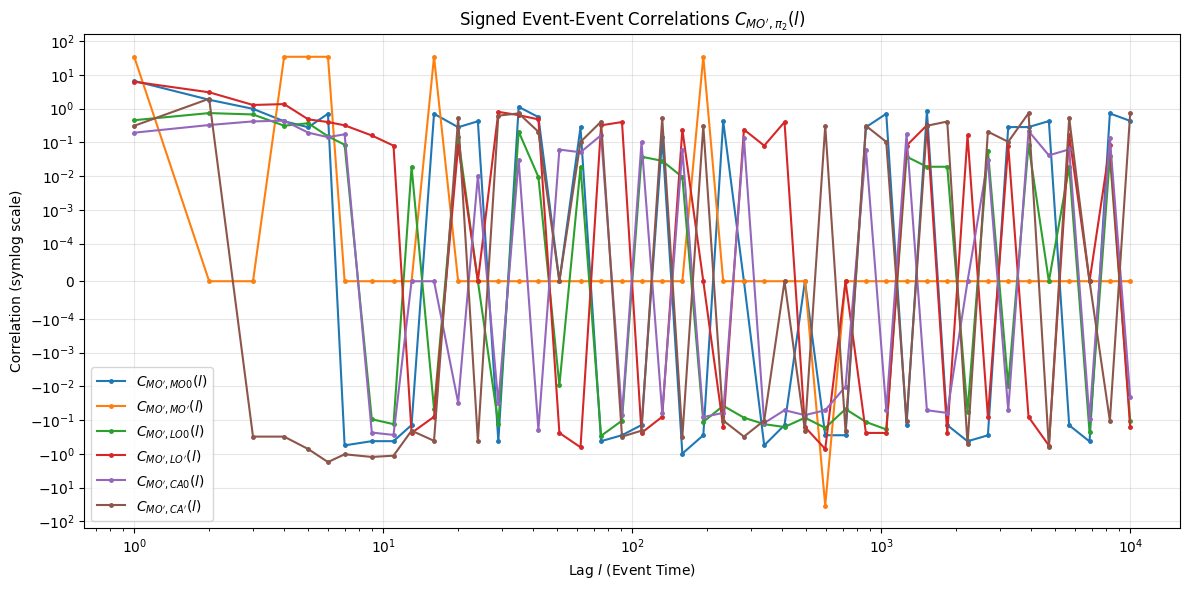

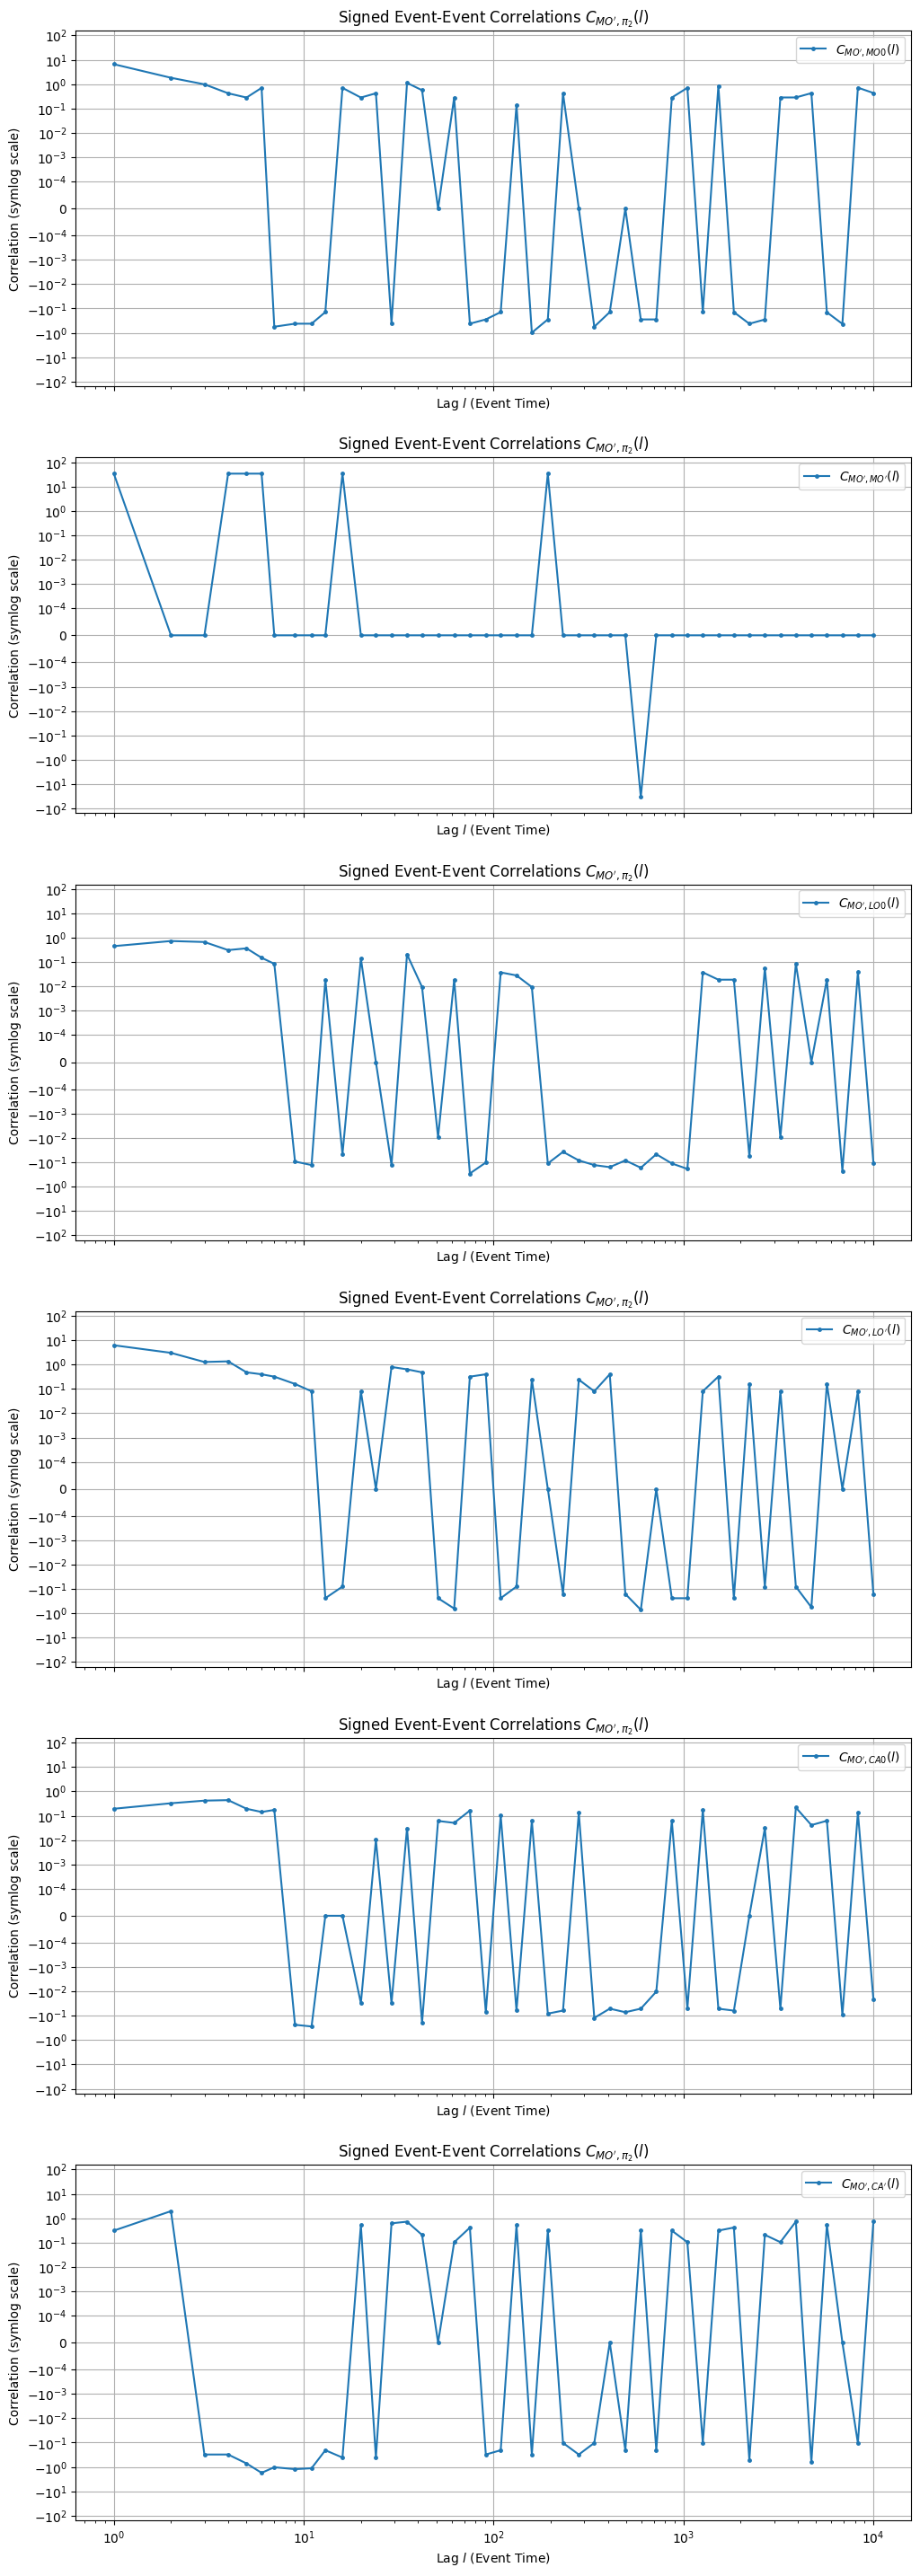

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))
for pi2 in types:
    ax.semilogx(lags, C_MO_prime[pi2], marker='.', markersize=5, label=f"$C_{{MO',{pi2}}}(l)$")
ax.set_yscale('symlog', linthresh=1e-4)
ax.set_title("Signed Event-Event Correlations $C_{MO',\\pi_2}(l)$")
ax.set_xlabel('Lag $l$ (Event Time)')
ax.set_ylabel('Correlation (symlog scale)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Detailed view
fig, ax = plt.subplots(6, 1, figsize=(12, 36), sharex=True, sharey=True)
ax = ax.flatten()
for i,pi2 in enumerate(types):
    ax[i].semilogx(lags, C_MO_prime[pi2], label=f"$C_{{MO',{pi2}}}(l)$", marker='.', markersize=5)
    ax[i].set_yscale('symlog', linthresh=1e-4)
    ax[i].set_title("Signed Event-Event Correlations $C_{MO',\\pi_2}(l)$")
    ax[i].set_xlabel('Lag $l$ (Event Time)')
    ax[i].set_ylabel('Correlation (symlog scale)')
    ax[i].legend()
    ax[i].grid(True)
plt.show()

<blockquote>

The signed event-event correlations ($C_{MO',\pi_2}(l)$) between aggressive market orders and subsequent limit order book events across event-time lags show extremely noisy oscillations between positive and negative values, with no clear decay pattern. This high volatility could be due to a number of factors, including the limited 5-day sample size, numerical instability or data sparsity. 

We do however note plateau-like behavior in the correlation functions for some event types, such as the negative correlation between $MO'$ and $CA'$ at short lags, which is consistent with the idea that aggressive market orders often trigger cancellations at the best as liquidity providers react to the price impact. Other similar patterns can be observed almost every correlation plot.

</blockquote>

5. Compute the theoretical responses in the constant impact model, and compare them to the empirical ones. Comment.

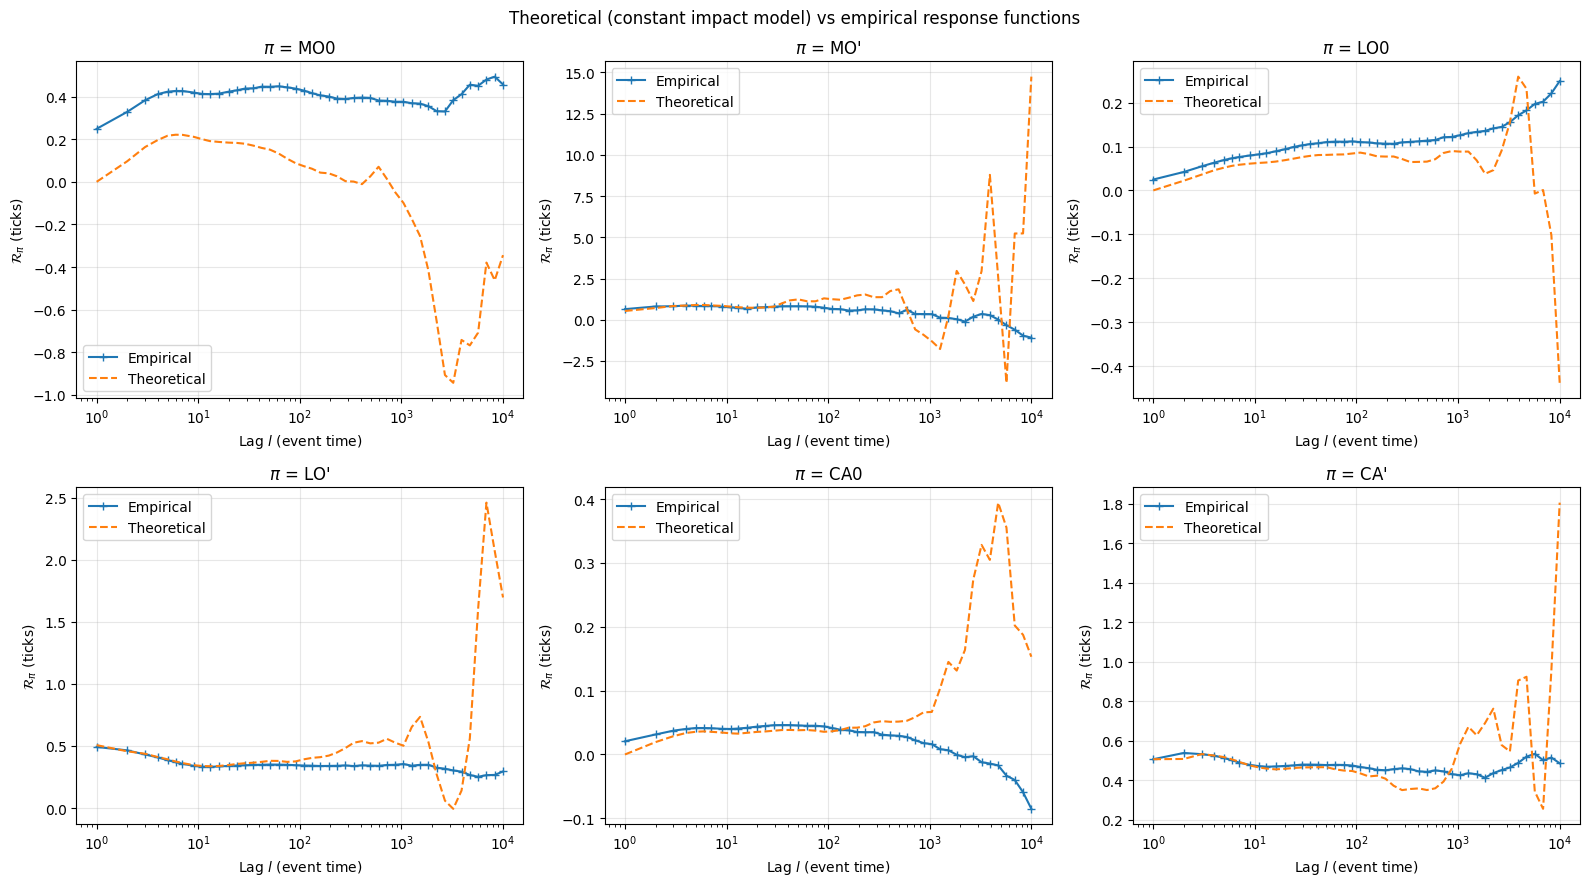

In [31]:
# Delta R^pi = average immediate price impact in ticks
delta_R_sum = {pi: 0.0 for pi in types}
delta_R_count = {pi: 0 for pi in types}

for u_day in events_per_day:
    gap_vals = u_day['gap'].values
    etype = u_day['event_type'].values

    for pi in types:
        mask = (etype == pi)
        if mask.any():
            delta_R_sum[pi] += np.sum(gap_vals[mask])
            delta_R_count[pi] += mask.sum()

# Normalize gap by tick size to get Delta R in ticks
delta_R = {pi: (delta_R_sum[pi] / delta_R_count[pi] / tick_size if delta_R_count[pi] > 0 else 0.0) for pi in types}

w = {pi1: delta_R[pi1] * event_probs[pi1] for pi1 in types}
max_lag = int(lags[-1])
int_lags = np.arange(0, max_lag + 1)

C_int = {}
for pi in types:
    C_int[pi] = {}
    for pi1 in types:
        vals = C_interp[pi][pi1](int_lags).copy()
        vals[0] = (1.0 / event_probs[pi]) if (pi == pi1 and event_probs[pi] > 0) else 0.0
        C_int[pi][pi1] = vals

theoretical_R_pi = {pi: np.zeros(len(lags)) for pi in types}
for pi in types:
    cumsum_total = np.zeros(max_lag + 1)
    for pi1 in types:
        integrand = w[pi1] * C_int[pi][pi1]
        cumsum_total += np.cumsum(integrand)
    for l_idx, l_val in enumerate(lags):
        theoretical_R_pi[pi][l_idx] = cumsum_total[l_val - 1]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for idx_pi, pi in enumerate(types):
    ax = axes[idx_pi // 3][idx_pi % 3]
    ax.semilogx(lags, R_pi[pi][:len(lags)], label='Empirical', marker='+')
    ax.semilogx(lags, theoretical_R_pi[pi], label='Theoretical', linestyle='--')
    ax.set_title(f'$\\pi$ = {pi}')
    ax.set_xlabel('Lag $l$ (event time)')
    ax.set_ylabel('$\\mathcal{R}_\\pi$ (ticks)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Theoretical (constant impact model) vs empirical response functions')
plt.tight_layout()
plt.show()

<blockquote>

The theoretical response functions from the constant impact model capture the qualitative shape of the empirical responses very well at short to medium lags ($l \leq 10^2$), but diverge significantly at longer lags.

For aggressive events that establish new best quotes ($MO′, LO′, CA′$), the agreement is exceptionally close early on. This confirms that the immediate price impact is well-approximated by the average gap $\Delta \mathcal{R}^\pi$. The theoretical model successfully predicts a non-zero response for the passive events ($LO^0$ and $CA^0$), and shows the upward drift. This validates that the model correctly captures how passive events, despite having zero initial mechanical impact, accumulate a response via their cross-correlations with subsequent price-moving events in the order flow. The main exception at short lags is $MO^0$, where the theoretical model consistently under-estimates the empirical response.

At longer lags ($l > 10^3$), the theoretical predictions become highly unstable and diverge wildly. This extreme oscillation is a direct consequence of summing over the highly noisy and volatile empirical event-event correlations ($C_{\pi_1,\pi_2}(l)$) caused by our limited 5-day sample size.

Overall, the comparison validates the propagator framework as a powerful first-order model for LOB event impact, while highlighting the need for much larger datasets to stabilize the correlation matrix inputs at longer horizons.

</blockquote>